# Tuning
This notebook summarises the workflow of tuning and tracking resonators using `sodetlib`. This is typically all you need,
but it won't give you all the information to understand what is going on under the hood. The step-by-step process is
available in [the docs](https://sodetlib.readthedocs.io/en/latest/operations/setup.html).

You can find more details in [The Appendix notebook](./Appendix.ipynb)
and in the [`sodetlib` docs](https://sodetlib.readthedocs.io/en/latest/interactive_setup.html#tuning-on-resonators).

In [51]:
import matplotlib
matplotlib.use('Agg')

In [52]:
%matplotlib inline

In [53]:
import numpy as np
import time
import pysmurf.client
import matplotlib.pyplot as plt
from sodetlib.det_config import DetConfig

To start tuning the first step is to instantiate a SmurfControl object. Typcally, this is stored under the variable S.

To load the SmurfControl object, use the DetConfig class described in the sodetlib tutorial. This will pull
configuration files from your `$OCS_CONFIG_DIR` and correctly load a SmurfControl object for the specified
slot.  

Additional keyword arguments can be passed to the SmurfControl class via this function. See the [SmurfControl](https://pysmurf.readthedocs.io/en/main/client/base.html#module-pysmurf.client.base.smurf_control) docs for more info on allowed parameters.

In [54]:
cfg = DetConfig()
cfg.load_config_files(slot=2)
S = cfg.get_smurf_control(dump_configs=True, make_logfile=True)

This SmurfControl object is the way in which we interact with the Cryostat. In the rest of this notebook we will walk through starting up a slot and tuning resonators.

These operations are collected at a high level in the `sodetlib.uxm_setup` module.

## Setting Amplifier Biases
Target amplifier bias currents should be set in your device config file:

In [43]:
print(f"50k target current: {cfg.dev.exp['amp_50k1_drain_current']}\tHemt target current: {cfg.dev.exp['amp_hemt1_drain_current']}")

50k target current: 14	Hemt target current: 8


The `setup_amps` function will scan over gate voltages to optimise the drain currents to these targets.

In [ ]:
uxm_setup.setup_amps(S, cfg)

If you need to adjust these manually, you can use the `pysmurf` functions:

In [55]:
# aim for 4mA
S.set_amp_drain_voltage('hemt1',0.5)
S.set_amp_gate_voltage('hemt1',0.4,override=True)

# Bias RFC1 50K LNA -- aim for 21mA
S.set_amp_drain_voltage('50k1',5.0)
S.set_amp_gate_voltage('50k1',0.0)

print(S.get_amplifier_biases()) 

{'hemt_Vg': -0.7999967232, 'hemt_Id': 7.966406225, '50K_Vg': -0.5139759744, '50K_Id': 13.6640625}


You can turn off power to an amplifier by disabling its drain power.

In [ ]:
# only run this if you want this amp off
S.set_amp_drain_enable("50k1", False)

## Tuning with `sodetlib`

First, `setup_phase_delay` will measure the total delay (cable transmission and digital processing) in the system.

In [ ]:
uxm_setup.setup_phase_delay(S, cfg)

Next, `setup_tune` will perform resonator tuning by stepping through:
- a coarse scan of each band to identify resonator locations
- a finer scan and gradient descent algorithm to pin point each resonance center frequency
- a measurement of the `eta` parameter to calibrate the measured $S_{21}$ into a center frequency shift

In [ ]:
uxm_setup.setup_tune(S, cfg, show_plots=True)

## Tracking Setup with `sodetlib`
The `optimize_params` package in `sodetlib` has a function `optimize_tracking` that does the above operation for you and updates your `dev_cfg` with the optimized `fraction_full_scale` value 

In [ ]:
from sodetlib.smurf_funcs.optimize_params import optimize_tracking

In [24]:
lms_freq, frac_pp, track_dict = optimize_tracking(S, cfg, band)

4
Loading tune and running initial tracking setup
Number of bad tracking channels 0
Optimized frac_pp: 0.27995131302902976 for lms_freq = 20000.0


(array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00016994],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00017223],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00017452],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00022945],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00023174],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00023403]]),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00016994],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00017223],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00017452],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00022945],
        [0. 

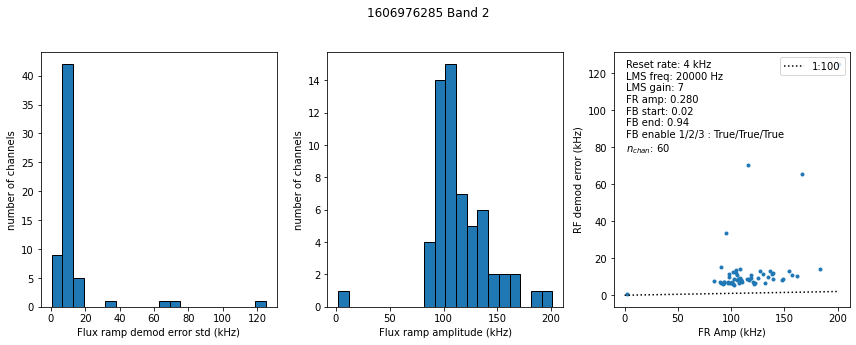

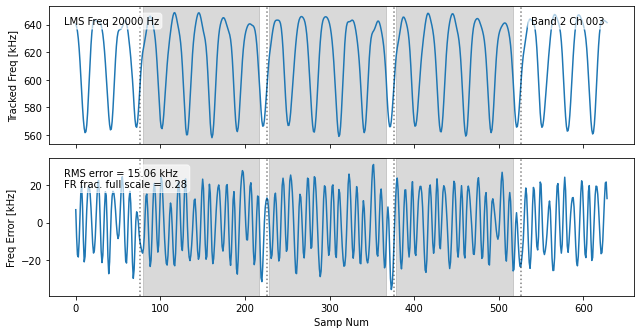

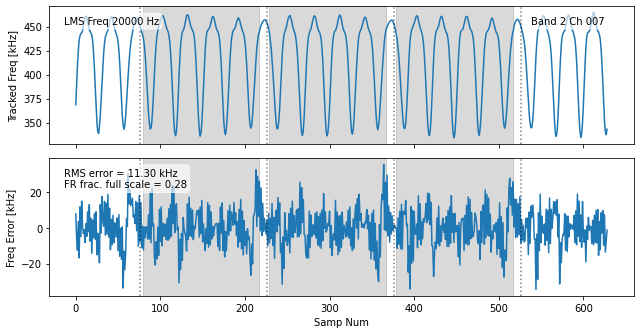

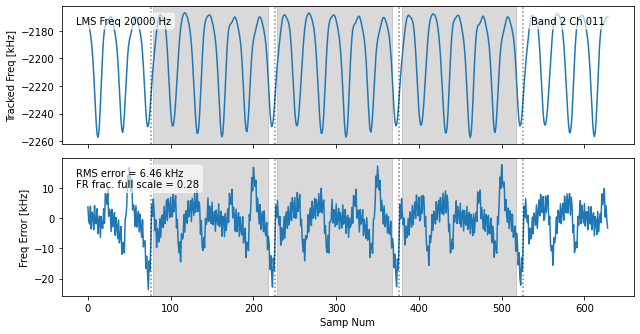

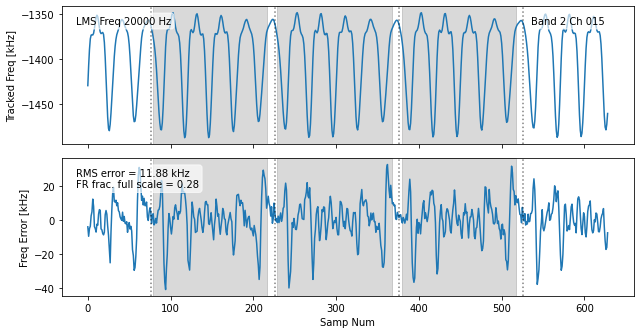

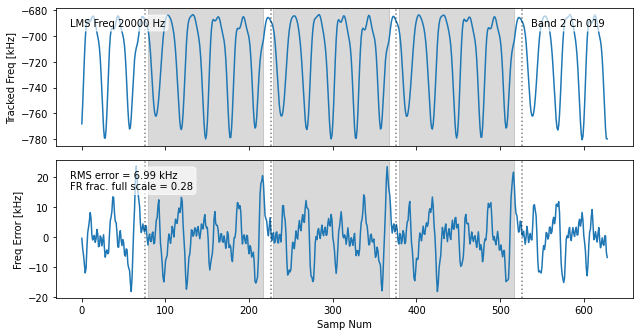

In [58]:
S.tracking_setup(band,reset_rate_khz=4,lms_freq_hz=band_cfg['lms_freq_hz'],meas_lms_freq=False,
                 fraction_full_scale=band_cfg['frac_pp'],make_plot=True,show_plot=True,
                 channel=S.which_on(band)[:5],nsamp=2**18,feedback_start_frac=0.02,feedback_end_frac=0.94)

Now we should be tracking well and ready to use our readout system (i.e. stream data for noise, bolometer signals, etc.).

But we can also identify and kill channels that aren't tracking well in two ways, first is using check_lock. When using `check_lock` optimizing the optional arguments is really important. For that reason we often do this step by hand instead because if you don't get the optional arguments right `check_lock` can turn off channels that are working fine and/or not turn off enough bad tracking channels.

In [ ]:
S.check_lock(band)

If you want to kill channels by hand you just flip through the individual channel plots and write down into a list the channels that look like they're tracking poorly then turn them off. I'll call this list of bad channel, `bad_chans`.

In [ ]:
bad_chans = []
for chan in bad_chans:
    S.channel_off(band,chan)

## Streaming Data
After killing poorly tracking channels you can now stream data, this can be done in a few ways:
- **take_noise_psd** takes a timestream of specified length then calculates its ASD and fits for white noise level, $f_{knee}$, and the low frequency noise power law index. It also produces some nice summary plots and we often use the summary plot as a check that we're getting a median white noise levl we expect (for resonator only channels this should be ~30-40pA/rtHz)
- **take_stream_data** takes a timestream of specified length
- **stream_data_on/off** streams data indefinitely until stopped

In [ ]:
S.take_noise_psd(meas_time=10,low_freq=[1],high_freq=[10],nperseg=2**16,
                 save_data=True,show_plot=True,make_channel_plot=True,
                 channel = S.which_on(band)[:5])

In [ ]:
datfile_tsd = S.take_stream_data(10)

In [ ]:
datfile_sdo = S.stream_data_on()
time.sleep(10)
S.stream_data_off()

## Relocking a tune

If a tune file has been generated already, it is not necessary to go through the the full tuning process again.
The `uxm_relock` operation will:
1. Reset state (all off, disable waveform, etc.)
2. Set amps and check tolerance
3. load tune, setup_notches, serial grad descent and eta scan
4. Tracking setup
5. Measure noise

It is documented [here](https://sodetlib.readthedocs.io/en/latest/operations/setup.html#relocking).

In [ ]:
from sodetlib.operations import uxm_relock

uxm_relock.uxm_relock(S, cfg, show_plots=True)